# Identifikasi Masalah

## Latar Belakang
Dataset berisi data transaksi perusahaan e-commerce. Informasi transaksi dapat digunakan untuk menganalisis perilaku pelanggan, performa produk dan tren penjualan. Insight dari analisis dapat digunakan untuk memberikan rekomendasi keputusan strategi pemasaran dan manajemen stok.

## Topik Permasalahan
Analisis perilaku pelanggan dan performa penjualan e-commerce untuk mengidentifikasi peluang peningkatan pendapatan dan strategi pemasaran.

## Problem Statement

**SMART Framework**
1. Specific: Megidentifikasi faktor utama yang mempengaruhi penjualan dan perilaku pelanggan pada tahun 2019.
2. Measurable: Mengukur metrik seperti pendapatan, jumlah penjualan, kontribusi negara, frekuensi pembelian pelanggan, dan nilai transaksi.
3. Achievable: Analisis dilakukan menggunakan dataset transaksi historis dengan metode visualisasi dan statistik.
4. Relevant: Insight dari analisis dapat membantu dalam mengambil keputusan untuk strategi pemasaran dan manajemen stok tahun 2020.
5. Time-bound: Periode analisis data transaksi tahun 2019.

**Problem Statement**

Menganalisis perilaku pelanggan, performa produk, dan tren penjualan e-commerce pada tahun 2019 untuk mengidentifikasi faktor-faktor utama yang memengaruhi penjualan dan memberikan rekomendasi strategi bisnis untuk meningkatkan pendapatan pada tahun 2020.

## Penjabaran Masalah
1. Bagaimana tren penjualan dan pendapatan perusahaan pada tahun 2019?
2. Produk apa saja yang memberikan total pendapatan dan jumlah penjualan terbesar?
3. Negara mana yang memberikan total pendapatan terbesar?
4. Bagaimana pola pembelian pelanggan berdasarkan frekuensi jumlah transaksi?
5. Bagaimana distribusi nilai transaksi dan jumlah pembelian per transaksi?
6. Apakah terdapat perbedaan signifikan rata-rata pengeluaran antara bulk buyers dan regular customers? 

# Import Libraries

In [1]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# Data Loading

In [ ]:
# Load data menjadi DataFrame
df = pd.read_csv('data/sales_transaction_raw.csv')

# Cek DataFrame
df

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom
...,...,...,...,...,...,...,...,...
536345,C536548,12/1/2018,22168,Organiser Wood Antique White,18.96,-2,12472.0,Germany
536346,C536548,12/1/2018,21218,Red Spotty Biscuit Tin,14.09,-3,12472.0,Germany
536347,C536548,12/1/2018,20957,Porcelain Hanging Bell Small,11.74,-1,12472.0,Germany
536348,C536548,12/1/2018,22580,Advent Calendar Gingham Sack,16.35,-4,12472.0,Germany


In [3]:
# Cek informasi dan struktur data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB


In [4]:
# Cek informasi statistik deskriptif data numerik
df.describe()

,Price,Quantity,CustomerNo
count,536350.000000,536350.000000,536295.000000
mean,12.662182,9.919347,15227.893178
std,8.490450,216.662300,1716.582932
min,5.130000,-80995.000000,12004.000000
25%,10.990000,1.000000,13807.000000
50%,11.940000,3.000000,15152.000000
75%,14.090000,10.000000,16729.000000
max,660.620000,80995.000000,18287.000000


# Data Cleaning

## Handle Cancelled Order (Negative Quantity)

In [5]:
# Hapus baris dengan quantity negative
df = df[df['Quantity'] > 0]

In [6]:
# Cek informasi statistik deskriptif data numerik
df.describe()

,Price,Quantity,CustomerNo
count,527765.000000,527765.000000,527764.000000
mean,12.629636,10.594674,15231.626733
std,7.933217,156.786646,1716.522182
min,5.130000,1.000000,12004.000000
25%,10.990000,1.000000,13813.000000
50%,11.940000,3.000000,15159.000000
75%,14.090000,11.000000,16729.000000
max,660.620000,80995.000000,18287.000000


## Handle Missing Values

In [7]:
# Cek missing values dalam persentase
df.isnull().sum()

TransactionNo    0
Date             0
ProductNo        0
ProductName      0
Price            0
Quantity         0
CustomerNo       1
Country          0
dtype: int64

In [8]:
# Hapus missing values
df = df.dropna()

In [9]:
# Cek missing values dalam persentase
df.isnull().sum()

TransactionNo    0
Date             0
ProductNo        0
ProductName      0
Price            0
Quantity         0
CustomerNo       0
Country          0
dtype: int64

## Handle Duplicate Data

In [10]:
# Cek duplicate data
df.duplicated().sum()

np.int64(5163)

In [11]:
# Hapus duplicate data
df.drop_duplicates(inplace=True)

In [12]:
# Cek duplicate data
df.duplicated().sum()

np.int64(0)

## Handle Inconsistent Data

In [13]:
# Cek tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 522601 entries, 0 to 536324
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  522601 non-null  object 
 1   Date           522601 non-null  object 
 2   ProductNo      522601 non-null  object 
 3   ProductName    522601 non-null  object 
 4   Price          522601 non-null  float64
 5   Quantity       522601 non-null  int64  
 6   CustomerNo     522601 non-null  float64
 7   Country        522601 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 35.9+ MB


In [14]:
# Ubah tipe data
df = df.astype({'Date': 'datetime64[ns]', 'CustomerNo': 'object'})

In [15]:
# Cek tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 522601 entries, 0 to 536324
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionNo  522601 non-null  object        
 1   Date           522601 non-null  datetime64[ns]
 2   ProductNo      522601 non-null  object        
 3   ProductName    522601 non-null  object        
 4   Price          522601 non-null  float64       
 5   Quantity       522601 non-null  int64         
 6   CustomerNo     522601 non-null  object        
 7   Country        522601 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 35.9+ MB


## Filter and Sort Data 2019

In [16]:
# Filter data
df = df[df['Date'].dt.year > 2018]

# Sort data
df = df.sort_values('Date')

## Validate Data

In [17]:
# Cek data
df

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
494247,540098,2019-01-04,21623,Vintage Union Jack Memoboard,20.45,1,16241.0,United Kingdom
493486,540026,2019-01-04,22376,Airline Bag Vintage Jet Set White,14.57,1,12026.0,United Kingdom
493485,540026,2019-01-04,22372,Airline Bag Vintage World Champion,14.57,2,12026.0,United Kingdom
493484,540026,2019-01-04,22371,Airline Bag Vintage Tokyo 78,14.57,5,12026.0,United Kingdom
493483,540026,2019-01-04,22346,Party Pizza Dish Green Polkadot,10.69,1,12026.0,United Kingdom
...,...,...,...,...,...,...,...,...
1079,581498,2019-12-09,21935,Suki Shoulder Bag,6.19,7,14498.0,United Kingdom
1080,581498,2019-12-09,21942,Skulls Design Flannel,6.19,1,14498.0,United Kingdom
1081,581498,2019-12-09,21955,Doormat Union Jack Guns And Roses,6.19,1,14498.0,United Kingdom
1071,581498,2019-12-09,21874,Gin And Tonic Mug,6.19,2,14498.0,United Kingdom


In [18]:
# Cek informasi dan struktur data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 481702 entries, 494247 to 0
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionNo  481702 non-null  object        
 1   Date           481702 non-null  datetime64[ns]
 2   ProductNo      481702 non-null  object        
 3   ProductName    481702 non-null  object        
 4   Price          481702 non-null  float64       
 5   Quantity       481702 non-null  int64         
 6   CustomerNo     481702 non-null  object        
 7   Country        481702 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 33.1+ MB


In [19]:
# Cek informasi statistik deskriptif data numerik
df.describe(include=['int', 'float'])

,Price,Quantity
count,481702.000000,481702.000000
mean,12.511357,10.831250
std,7.574578,163.733043
min,5.130000,1.000000
25%,10.920000,1.000000
50%,11.940000,4.000000
75%,14.090000,12.000000
max,660.620000,80995.000000


## Export Clean Data

In [ ]:
df.to_csv('data/sales_transaction_clean.csv', index=False)

# Analisis dan Perhitungan

## 1. Tren Penjualan dan Pendapatan Perusahaan Tahun 2019

In [21]:
# Buat kolom revenue
df['Revenue'] = df['Price'] * df['Quantity']

# Buat kolom month
df['Month'] = df['Date'].dt.month

<Axes: title={'center': 'Sales 2019'}, xlabel='Month'>

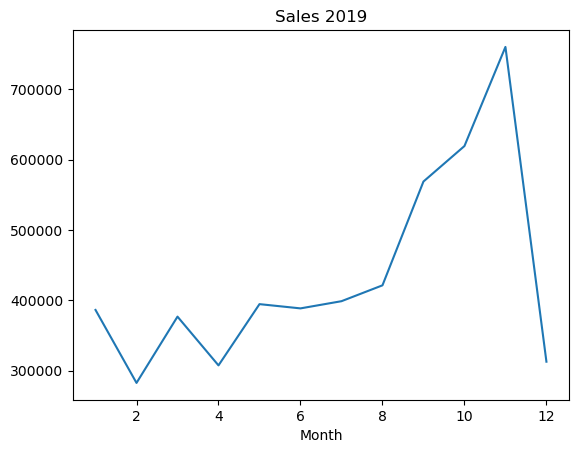

In [22]:
# Tren penjualan
df.groupby('Month')['Quantity'].sum().plot(title='Sales 2019')

<Axes: title={'center': 'Revenue 2019'}, xlabel='Month'>

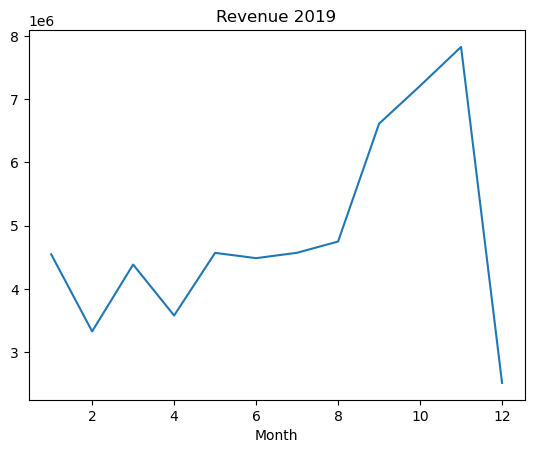

In [23]:
# Tren pendapatan
df.groupby('Month')['Revenue'].sum().plot(title='Revenue 2019')

### Insight
Penjualan dan pendapatan relatif stabil pada awal hingga pertengahan 2019 dan mengalami peningkatan pesat di Bulan September 2019 yang menunjukkan adanya pola musiman.

## 2. Produk dengan Total Pendapatan dan Jumlah Penjualan Terbesar

<Axes: title={'center': 'Top 10 Products by Revenue'}, xlabel='ProductName'>

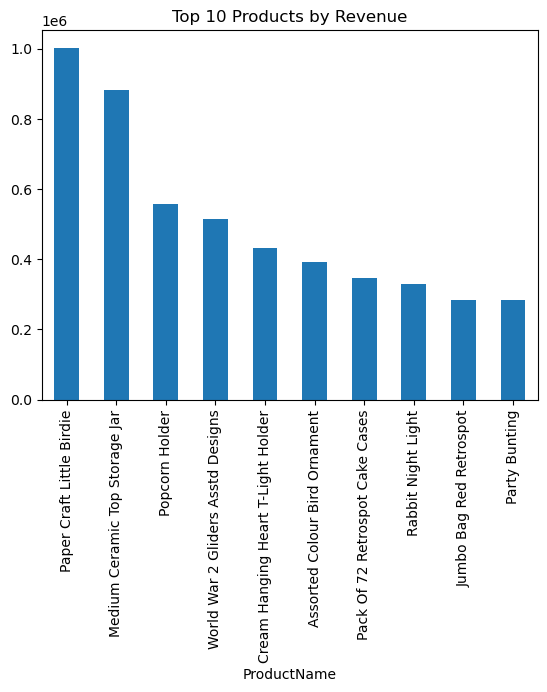

In [24]:
# Plot top 10 produk berdasarkan total pendapatan
df.groupby('ProductName')['Revenue'].sum().sort_values(ascending=False).head(10).plot(kind='bar', title='Top 10 Products by Revenue')

<Axes: title={'center': 'Top 10 Products by Quantity'}, xlabel='ProductName'>

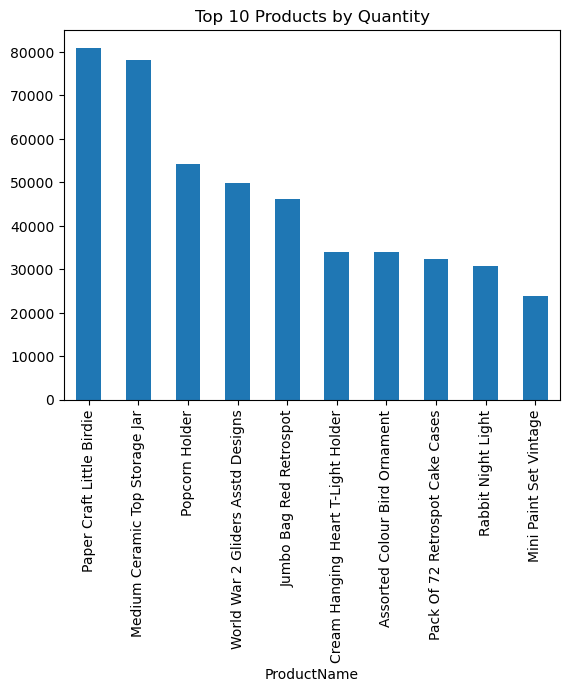

In [25]:
# Plot top 10 produk berdasarkan jumlah penjualan
df.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False).head(10).plot(kind='bar', title='Top 10 Products by Quantity')

### Insight
Paper craft little birdie dan medium ceramic top storage jar merupakan produk dengan total pendapatan dan jumlah penjualan terbesar pada tahun 2019 dibandingkan dengan produk lainnya.

## 3. Negara dengan Total Pendapatan Terbesar

<Axes: title={'center': 'Top 10 Countries by Revenue'}, xlabel='Country'>

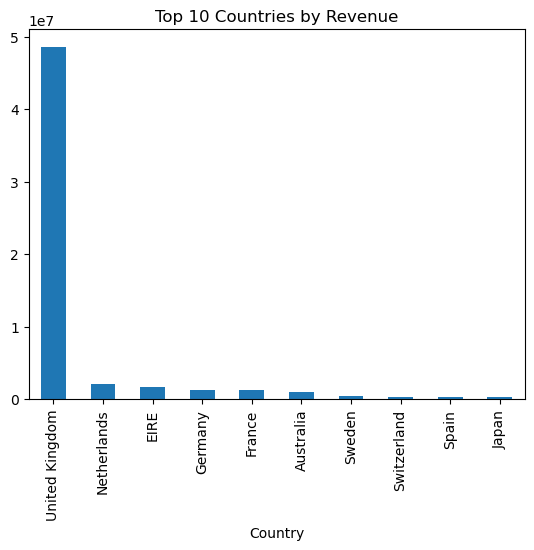

In [26]:
# Plot top 10 negara dengan total pendapatan terbesar
df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10).plot(kind='bar', title='Top 10 Countries by Revenue')

### Insight
United Kingdom memberikan kontribusi total pendapatan terbesar dibandingkan negara lainnya pada tahun 2019, Netherlands dan Eire (Ireland) menunjukkan potensi pasar internasional dengan kontribusi pendapatan yang relatif lebih kecil.

## 4. Pola Pembelian Pelanggan Berdasarkan Frekuensi Jumlah Transaksi

<Axes: title={'center': 'Distribution of Customer Purchase Frequency'}, ylabel='Frequency'>

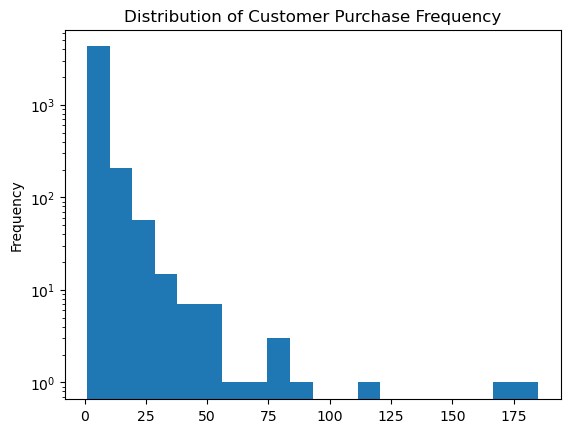

In [27]:
# Plot distribusi pelanggan berdasarkan jumlah transaksi
df.groupby('CustomerNo')['TransactionNo'].nunique().plot(kind='hist', bins=20, log=True, title='Distribution of Customer Purchase Frequency')

### Insight
Sebagian besar pelanggan melakukan transaksi dalam jumlah yang kecil, hanya sedikit pelanggan yang melakukan transaksi dalam jumlah yang besar. Ini mengindikasikan perusahaan memiliki banyak pelanggan yang hanya melakukan transaksi sekali saja.

## 5. Distribusi Nilai Transaksi dan Jumlah Pembelian per Transaksi

<Axes: title={'center': 'Distribution of Revenue per Transaction'}, ylabel='Frequency'>

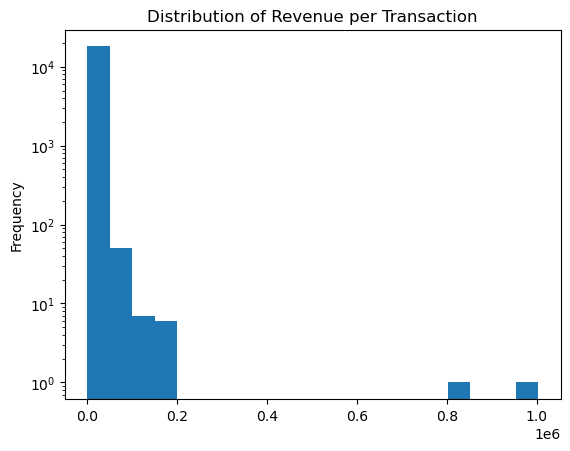

In [28]:
# Plot total pendapatan berdasarkan transaksi
df.groupby('TransactionNo')['Revenue'].sum().plot(kind='hist', bins=20, log=True, title='Distribution of Revenue per Transaction')

<Axes: title={'center': 'Distribution of Quantity per Transaction'}, ylabel='Frequency'>

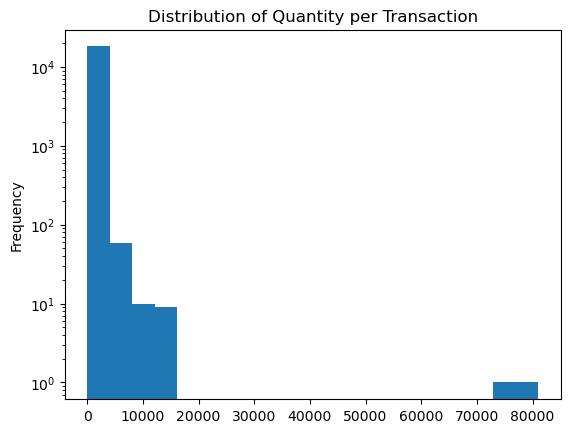

In [29]:
# Plot total jumlah penjualan berdasarkan transaksi
df.groupby('TransactionNo')['Quantity'].sum().plot(kind='hist', bins=20, log=True, title='Distribution of Quantity per Transaction')

In [30]:
# Informasi statistik deskriptif total pendapatan berdasarkan transaksi
df.groupby('TransactionNo')['Revenue'].sum().describe().apply(lambda x: f'{x:.2f}')

count      18237.00
mean        3201.38
std        11627.38
min            5.46
25%          841.17
50%         1745.17
75%         3345.30
max      1002718.10
Name: Revenue, dtype: object

In [31]:
# Informasi statistik deskriptif total jumlah penjualan berdasarkan transaksi
df.groupby('TransactionNo')['Quantity'].sum().describe()

count    18237.00000
mean       286.09064
std        993.72318
min          1.00000
25%         72.00000
50%        157.00000
75%        304.00000
max      80995.00000
Name: Quantity, dtype: float64

In [32]:
# Median total pendapatan berdasarkan transaksi
df.groupby('TransactionNo')['Revenue'].sum().median()

1745.17

In [33]:
# Median total jumlah penjualan berdasarkan transaksi
df.groupby('TransactionNo')['Quantity'].sum().median()

157.0

### Insight
Distribusi nilai transaksi dan jumlah penjualan per transaksi menunjukkan right-skewed. Median nilai transaksi lebih rendah daripada nilai rata-rata dan memiliki nilai maksimum yang sangat tinggi, mengindikasikan adanya outliers yang meningkatkan nilai rata-rata. Distribusi jumlah penjualan per transaksi menunjukkan pola yang serupa, perbedaan yang besar antara nilai rata-rata dan nilai median serta nilai maksimum yang sangat tinggi menunjukkan bahwa sebagian kecil transaksi dilakukan dalam jumlah yang sangat besar.

## 6. Perbedaan Rata-Rata Pengeluaran Antara Bulk Buyers dan Regular Customers

### Data Preparation

In [34]:
# Buat data pelanggan
customer = df.groupby('CustomerNo').agg(
    total_transaction = ('TransactionNo', 'nunique'),
    total_revenue = ('Revenue', 'sum')
)

In [35]:
# Quartile 75% total transaksi untuk ketentuan bulk buyers
customer['total_transaction'].quantile(0.75)

np.float64(4.0)

In [36]:
# Tipe pelanggan
customer['buyer_type'] = 'Regular'
customer.loc[customer['total_transaction'] > 4, 'buyer_type'] = 'Bulk'


In [37]:
# Cek data pelanggan
customer

,total_transaction,total_revenue,buyer_type
CustomerNo,,,
12004.0,1,1509.60,Regular
12006.0,1,24.76,Regular
12008.0,1,5689.57,Regular
12024.0,1,149.52,Regular
12025.0,1,1021.59,Regular
...,...,...,...
18280.0,1,623.26,Regular
18281.0,1,576.58,Regular
18282.0,2,1044.86,Regular


### Hypothesis Testing

#### Hipotesis
H0: Tidak terdapat perbedaan rata-rata pengeluaran antara bulk buyers dan regular customers.

H1: Bulk buyers memiliki rata-rata pengeluaran lebih tinggi dibandingkan regular customers.

In [38]:
# Buat data pendapatan berdasarkan tipe pelanggan
bulk = customer[customer['buyer_type'] == 'Bulk']['total_revenue']
regular = customer[customer['buyer_type'] == 'Regular']['total_revenue']

In [39]:
# Two-sample t-test
t_stat, p_value = stats.ttest_ind(bulk, regular)

# Menampilkan t-statistic dan p-value
print(f'T-Statistic: {t_stat}')
print(f'P-Value: {p_value}')

# Uji hipotesis
alpha = 0.05
if p_value < alpha:
    print('H0 ditolak: Bulk buyers memiliki rata-rata pengeluaran lebih tinggi dibandingkan regular customers.')
else:
    print('H0 gagal ditolak: Tidak terdapat perbedaan rata-rata pengeluaran antara bulk buyers dan regular customers.')

T-Statistic: 16.301127355628413
P-Value: 4.109274161123075e-58
H0 ditolak: Bulk buyers memiliki rata-rata pengeluaran lebih tinggi dibandingkan regular customers.


### Insight
Hasil uji hipotesis menunjukkan nilai p-value lebih kecil dari nilai alpha (0.05), maka H0 ditolak, artinya terdapat perbedaan signifikan antara rata-rata pengeluaran bulk buyers dan regular customers. Bulk buyers memiliki rata-rata pengeluaran yang lebih tinggi dibanding pelanggan reguler dan memberikan kontribusi besar terhadap pendapatan perusahaan.

# Pengambilan Kesimpulan

## Tujuan Bisnis
Menganalisis perilaku pelanggan, performa produk, dan tren penjualan e-commerce pada tahun 2019 untuk mengidentifikasi faktor-faktor utama yang memengaruhi penjualan dan memberikan rekomendasi strategi bisnis untuk meningkatkan pendapatan pada tahun 2020.

## Kesimpulan
1. Tren penjualan dan pendapatan tahun 2019 menunjukkan pola musiman dengan peningkatan signifikan akhir tahun.
2. Sebagian kecil produk memberikan kontribusi mayoritas pendapatan dan jumlah penjualan.
3. United Kingdom memberikan kontribusi total pendapatan terbesar dibandingkan negara lainnya.
4. Sebagian besar pelanggan melakukan transaksi dalam jumlah yang kecil, sedangkan sebagian kecil pelanggan melakukan transaksi dalam jumlah yang besar.
5. Distribusi nilai transaksi dan jumlah penjualan menunjukkan adanya transaksi dalam jumlah besar yang berkontribusi signifikan terhadap total pendapatan.
6. Uji hipotesis menunjukkan bahwa bulk buyers memiliki rata-rata pengeluaran yang signifikan lebih tinggi dibandingkan pelanggan reguler.

## Rekomendasi
- Meningkatkan strategi pemasaran dan perencanaan stok pada akhir tahun.
- Mengoptimalkan inventory untuk produk-produk dengan kontribusi pendapatan dan jumlah penjualan terbesar.
- Mempertimbangkan ekspansi pasar internasional dengan prioritas Netherlands dan Eire (Ireland), serta mempertahankan pasar utama United Kingdom.
- Meningkatkan retensi pelanggan regular melalui program loyalitas, promosi repeat purchase dan personalized marketing.
- Mengembangkan strategi khusus untuk bulk buyers dengan memberikan diskon volume, kontrak B2B dan program loyalitas.